# 7장 실습 — 양자화 말고 다른 길

2부의 앞 세 장은 같은 모델을 더 적은 비트로 표현하는 길을 다뤘다. 그 길에는 한계가 있다 — 5장에서 본 대로 비트를 내리면 행동이 바뀌고, 4장에서 본 대로 작은 모델은 양자화로 빨라지지도 않는다.

다른 길이 셋 있다.

- **증류** — 큰 정책의 행동을 작은 정책에 옮긴다. 구조 자체가 바뀐다
- **캐스케이드** — 대부분은 싼 모델로 처리하고, 어려울 때만 비싼 모델을 부른다
- **추측 디코딩** — 싼 모델이 먼저 내놓고 비싼 모델이 검증한다. 출력이 바뀌지 않는다는 것이 이 방법의 핵심이다

문헌의 성적표는 이렇다. Spec-VLA 는 추측 디코딩으로 **성공률을 건드리지 않고 1.42배**를 냈다. CEED-VLA 는 조기 종료로 실행 주파수를 **5.95 Hz 에서 25.60 Hz** 로 올렸다. SmolVLA 는 4억 5천만 파라미터로 CPU 에서도 돌고, 비동기 추론으로 같은 일을 **9.7초 대 13.75초**에 끝냈다.

이 노트북은 앞의 둘을 밀기 과제에서 직접 만든다.

실행 시간은 CPU에서 6분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MODEL = mujoco.MjModel.from_xml_string(XML)


class Vec:
    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

In [4]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


t0 = time.time()
POLICY = train_rl()
print(f"정책 학습 끝  ({time.time() - t0:.0f}s)")

정책 학습 끝  (65s)


## 교사에서 학생으로

교사는 방금 학습한 64-64 정책이다. 학생은 훨씬 작은 망이고, 교사가 내는 행동을 지도학습으로 흉내 낸다.

3권 8장에서 모방학습이 50~60 에포크로는 크게 덜 학습된다는 것을 확인했었다. 여기서도 150 에포크를 쓴다.

In [5]:
class Small(nn.Module):
    def __init__(self, h=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(8, h), nn.Tanh(),
                                nn.Linear(h, 2))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def collect(teacher, n=32, steps=400, seed=3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    X, Y = [], []
    for _ in range(steps):
        o = env.obs()
        ot = torch.from_numpy(o)
        with torch.no_grad():
            a = teacher.dist(ot).sample().numpy()
        X.append(o)
        with torch.no_grad():
            Y.append(teacher.pi(ot).numpy())
        env.step(a)
    return (torch.from_numpy(np.concatenate(X)),
            torch.from_numpy(np.concatenate(Y)))


def distill(teacher, h, epochs=150, seed=3):
    X, Y = DATA
    torch.manual_seed(seed)
    s = Small(h)
    opt = torch.optim.Adam(s.parameters(), 3e-3)
    n = X.shape[0]
    for _ in range(epochs):
        idx = torch.randperm(n)
        for k in range(0, n, 1024):
            j = idx[k:k + 1024]
            loss = ((s.pi(X[j]) - Y[j]) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
    return s


t0 = time.time()
DATA = collect(POLICY)
print(f"시연 {DATA[0].shape[0]:,}개  ({time.time() - t0:.0f}s)")
STUDENTS = {}
for h in (4, 8, 16):
    STUDENTS[h] = distill(POLICY, h)
    print(f"학생 h={h} 끝  ({time.time() - t0:.0f}s)")

시연 12,800개  (2s)


학생 h=4 끝  (3s)


학생 h=8 끝  (5s)


학생 h=16 끝  (6s)


In [6]:
def score(net, seed=999, n=200, reps=2):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    sc = []
    for _ in range(EP * reps):
        o = torch.from_numpy(env.obs())
        with torch.no_grad():
            a = net.dist(o).sample().numpy()
        sc += env.step(a)[2]
    return np.array(sc)


def latency(net, reps=3000, warm=300):
    x = torch.randn(1, 8)
    ts = []
    for i in range(reps + warm):
        t0 = time.perf_counter_ns()
        with torch.no_grad():
            net.pi(x)
        if i >= warm:
            ts.append(time.perf_counter_ns() - t0)
    return np.array(ts) / 1e3


t0 = time.time()
CAND = {"교사 64-64": POLICY}
for h in (16, 8, 4):
    CAND[f"학생 {h}"] = STUDENTS[h]
SC = {k: score(v) for k, v in CAND.items()}
LT = {k: latency(v) for k, v in CAND.items()}
print(f"평가 끝  ({time.time() - t0:.0f}s)")

print()
print(pad("후보", 14) + pad("파라미터", 11, True)
      + pad("p50 μs", 10, True) + pad("p99 μs", 10, True)
      + pad("성공률", 9, True) + pad("95% 구간", 15, True))
for k, net in CAND.items():
    n = sum(p.numel() for p in net.pi.parameters())
    sc = SC[k]
    lo, hi = wilson(sc.sum(), len(sc))
    print(pad(k, 14) + pad(f"{n:,}", 11, True)
          + pad(f"{np.percentile(LT[k], 50):.0f}", 10, True)
          + pad(f"{np.percentile(LT[k], 99):.0f}", 10, True)
          + pad(f"{sc.mean():.2f}", 9, True)
          + pad(f"[{lo:.2f}, {hi:.2f}]", 15, True))

평가 끝  (24s)

후보             파라미터    p50 μs    p99 μs   성공률       95% 구간
교사 64-64          4,866        34        84     0.91   [0.88, 0.93]
학생 16               178        23        59     0.63   [0.58, 0.67]
학생 8                 90        23        58     0.61   [0.56, 0.66]
학생 4                 46        23        58     0.62   [0.57, 0.67]


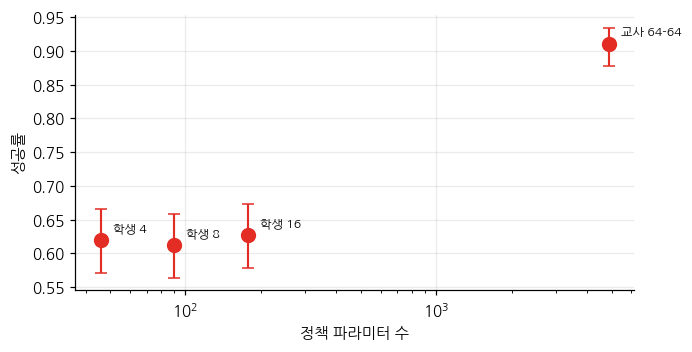

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 3.3))
ks = list(CAND)
npar = [sum(p.numel() for p in CAND[k].pi.parameters()) for k in ks]
ok = [SC[k].mean() for k in ks]
lo = [wilson(SC[k].sum(), len(SC[k]))[0] for k in ks]
hi = [wilson(SC[k].sum(), len(SC[k]))[1] for k in ks]
ax.errorbar(npar, ok, yerr=[np.array(ok) - lo, np.array(hi) - ok],
            fmt="o", color=RED, ms=9, capsize=4, lw=1.4)
for x, y, k in zip(npar, ok, ks):
    ax.annotate(k, (x, y), fontsize=8, xytext=(8, 5),
                textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("정책 파라미터 수")
ax.set_ylabel("성공률")
plt.tight_layout()
plt.show()

## 캐스케이드 — 어려울 때만 비싼 모델을 부른다

두 번째 길이다. 대부분의 스텝은 쉽고 몇몇 스텝만 어렵다면, 쉬운 스텝을 싼 모델에 맡기고 **어려울 때만** 교사를 부르면 된다.

문제는 「어려운지」를 어떻게 아는가이다. 여기서는 간단한 신호를 쓴다 — **학생이 낸 행동의 크기**다. 밀기 과제에서 큰 명령이 필요한 순간이 대체로 결정적인 순간이고, 작은 명령은 미세 조정이다. 4부에서 훨씬 제대로 된 불확실성 지표를 만들 것이므로, 여기서는 캐스케이드라는 **구조** 자체가 값을 하는지만 본다.

In [8]:
def cascade(student, teacher, thr, seed=999, n=200, reps=2):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    sc, calls, total = [], 0, 0
    for _ in range(EP * reps):
        o = torch.from_numpy(env.obs())
        with torch.no_grad():
            a = student.dist(o).sample()
            hard = a.abs().amax(dim=1) > thr
            if hard.any():
                b = teacher.dist(o).sample()
                a = torch.where(hard[:, None], b, a)
        calls += int(hard.sum())
        total += n
        sc += env.step(a.numpy())[2]
    return np.array(sc), calls / total


t0 = time.time()
S8 = STUDENTS[8]
print(pad("문턱", 10) + pad("교사 호출률", 14, True)
      + pad("성공률", 9, True) + pad("95% 구간", 15, True))
CAS = {}
for thr in (99., 1.2, .8, .5, .2, -1.):
    sc, rate = cascade(S8, POLICY, thr)
    CAS[thr] = (sc, rate)
    lo, hi = wilson(sc.sum(), len(sc))
    lab = {99.: "학생만", -1.: "교사만"}.get(thr, f"{thr:.1f}")
    print(pad(lab, 10) + pad(f"{rate * 100:.0f}%", 14, True)
          + pad(f"{sc.mean():.2f}", 9, True)
          + pad(f"[{lo:.2f}, {hi:.2f}]", 15, True))
print(f"\n({time.time() - t0:.0f}s)")

문턱         교사 호출률   성공률       95% 구간


학생만                0%     0.61   [0.56, 0.66]


1.2                  31%     0.78   [0.73, 0.82]


0.8                  56%     0.87   [0.83, 0.90]


0.5                  77%     0.90   [0.86, 0.92]


0.2                  96%     0.91   [0.88, 0.93]


교사만              100%     0.91   [0.88, 0.94]

(36s)


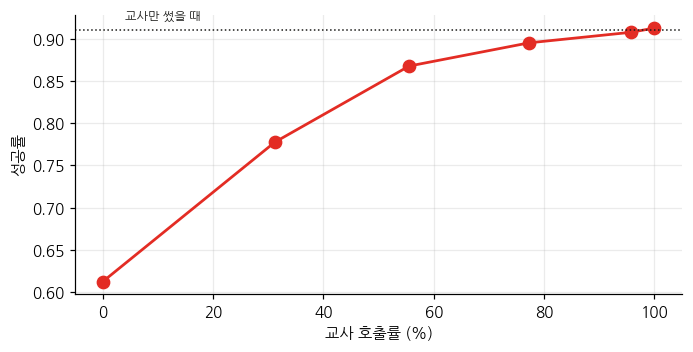

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 3.3))
rs = [CAS[t][1] * 100 for t in CAS]
os_ = [CAS[t][0].mean() for t in CAS]
o = np.argsort(rs)
ax.plot(np.array(rs)[o], np.array(os_)[o], "o-", color=RED,
        lw=1.8, ms=8)
ax.axhline(SC["교사 64-64"].mean(), color=INK, lw=1, ls=":")
ax.text(4, SC["교사 64-64"].mean() + .012, "교사만 썼을 때",
        fontsize=8, color=INK)
ax.set_xlabel("교사 호출률 (%)")
ax.set_ylabel("성공률")
plt.tight_layout()
plt.show()

## 출력을 바꾸지 않는 길

세 번째 길은 이 노트북에서 만들지 않는다. 밀기 과제의 정책은 자기회귀 디코딩을 쓰지 않아서 추측 디코딩을 붙일 자리가 없기 때문이다. 대신 그 성질을 적어 둔다.

**추측 디코딩은 출력을 바꾸지 않는다.** 싼 모델이 여러 토큰을 미리 내놓고 비싼 모델이 한 번에 검증해서, 받아들여진 토큰은 비싼 모델이 직접 냈을 토큰과 같다. 그래서 성공률이 보존된다 — Spec-VLA 가 1.42배를 내면서 성공률을 유지한 것이 이 성질 덕이다.

이 성질이 이 장의 다른 두 길과 대비된다. 증류와 캐스케이드는 **다른 정책을 만든다.** 빠른 만큼 다르게 행동하고, 얼마나 다른지는 재 봐야 안다. 추측 디코딩은 같은 정책을 빠르게 돌린다.

> 증류·양자화·캐스케이드 — 정책이 바뀐다, 재야 한다
> 추측 디코딩 — 정책이 그대로다, 속도만 잰다

자기회귀 VLA 를 쓴다면 이 구분이 선택의 순서를 정해 준다. **출력을 바꾸지 않는 기법을 먼저 쓰고**, 그것으로 부족할 때 바꾸는 기법으로 간다.

## 정리

**증류의 값은 이 규모에서 속도가 아니다.** 마이크로초 단위의 정책에서 파라미터를 줄여도 지연은 거의 그대로다. 값은 메모리와 전력, 그리고 더 작은 칩에 들어간다는 데 있다.

**행동이 얼마나 보존되는지가 증류의 질문이다.** 그리고 그 답은 학생의 크기에 따라 갈린다.

**캐스케이드는 호출률과 성적을 맞바꾼다.** 적은 호출로 교사에 가까운 성적이 나오면 값을 한 것이고, 그 판단에는 「어려운 순간」을 알아보는 신호가 필요하다. 4부가 그 신호를 제대로 만든다.

**출력을 바꾸지 않는 기법이 먼저다.** 추측 디코딩처럼 정책을 그대로 두는 방법은 속도만 재면 되고, 나머지는 전부 다시 재야 한다.

2부가 끝났다. 모델을 작게 만드는 길을 훑었고, 그 길마다 **무엇을 내주는지**를 같은 표로 쟀다. 3부는 방향을 바꾼다 — 모델을 작게 만드는 대신 **지연을 전제로 설계하는** 쪽이다.